## Shuffled vs. I.I.D. Draws from Discrete Distributions

When simulating heterogeneous-agent models, income shocks are drawn from a discrete approximation to the true shock distribution.  The standard approach draws each agent's shock independently (i.i.d.), so the empirical frequency of each outcome in a finite sample deviates from the target probabilities by sampling noise of order $O(1/\sqrt{N})$.

HARK's `DiscreteDistribution.draw(replicates=k)` offers an alternative: **shuffled draws** that match the target probabilities exactly by allocating $k$ copies of the minimal full-coverage sample, then randomly permuting the assignment across agents.  This eliminates sampling noise from the cross-sectional distribution of shocks in any single period.

This notebook demonstrates the difference and measures the gain.

**Related:**
- [PR #1691](https://github.com/econ-ark/HARK/pull/1691) — merged the `shuffle` parameter into HARK
- [PR #1244](https://github.com/econ-ark/HARK/pull/1244) — original (unmerged) reshuffling proposal
- [Harmenberg (2021)](https://doi.org/10.1016/j.jedc.2021.104185) — permanent-income-neutral measure (a complementary variance-reduction technique)

`# Set up the computational environment: (in JupyterLab, click the dots)`

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from HARK.distributions import DiscreteDistribution

# The key constraint: perfect $N$

Shuffle should only be used when the population size $N$ is an **exact multiple** of the minimum sample size.  For an equiprobable distribution with $J$ outcomes, that minimum is $J$ itself, so $N$ must be a multiple of $J$.  (More generally, if outcomes have probabilities $p_j = n_j / D$ in lowest terms, the minimum is $\text{lcm}$ of the denominators.)

At perfect $N$, shuffle assigns **exactly** $N/J$ agents to each outcome — zero leftover slots, zero sampling noise in the marginal frequencies.  This is a hard guarantee, not an approximation.

### Why this works: expectations are cross-sectional averages

As discussed in [Carroll (2024), *Solving Microeconomic Dynamic Stochastic Optimization Problems*](https://llorracc.github.io/SolvingMicroDSOPs) (Sections 6.2 and 10), the formula for computing an expectation over an equiprobable discrete approximation,

$$\mathbb{E}[g(\theta)] \approx \frac{1}{J}\sum_{j=1}^{J} g(\theta_j),$$

is **structurally identical** to the cross-sectional average of $J$ simulated agents each assigned one of the $J$ shock values.  When we simulate $N = k \cdot J$ agents using the shuffled draw — which assigns exactly $k$ agents to each $\theta_j$ — the cross-sectional average reproduces the expectation formula exactly:

$$\frac{1}{N}\sum_{i=1}^{N} g(\theta_i) = \frac{1}{J}\sum_{j=1}^{J} g(\theta_j).$$

This is why the shuffled-draw simulation has no sampling noise in the cross-sectional mean of any function of the shocks: the simulation **is** the expectation formula, replicated $k$ times.  

One useful implication of this point is that the use of this method of simulation eliminates a common category of bug, in which there is some subtle but numerically significant difference between the expectations calculated using the solution algorithm and the results of the simulation.  Such a bug is impossible when the formulae for expectations and simulation are identical.

### The `replicates` parameter

The `replicates` parameter handles the bookkeeping: `F.draw(replicates=k)` computes the minimal full-coverage size automatically, multiplies by $k$, and forces shuffled draws.  It warns if `1/p_j` is not an integer for some outcome.

To see the difference concretely, we draw $k = 5$ replicates (giving $N = 5 \times 4 = 20$) from a $J = 4$ equiprobable distribution using both methods.

# Minimum sample size $J_{\min}$ for general distributions

For an equiprobable distribution with $J$ outcomes, the minimum sample size is simply $J$.  For a general probability vector $(p_1, \ldots, p_J)$, we need the smallest positive integer $N$ such that $N \cdot p_j$ is a positive integer for every atom $j$.

**Computation.**  Express each $p_j$ as a fraction $n_j / d_j$ in lowest terms.  Then

$$J_{\min} = \operatorname{lcm}(d_1, \ldots, d_J).$$

### Product-of-conditional-inverses interpretation

When a distribution is a joint over independent shock dimensions, $J_{\min}$ factors as the **product** of the inverse conditional probabilities at each level of the hierarchy.

*Example:* Suppose the unemployment probability is $p_u = 0.05 = 1/20$, and conditional on employment there are $3$ equiprobable permanent shocks and $3$ equiprobable transitory shocks.  The joint distribution has $1 + 3 \times 3 = 10$ atoms:

| Atom | Probability | As fraction |
|------|------------|-------------|
| Unemployed | $0.05$ | $1/20$ |
| Each of 9 employed states | $0.95/9$ | $19/180$ |

The denominators are $20$ and $180$, so $J_{\min} = \operatorname{lcm}(20, 180) = 180$.  This equals the product of conditional inverses:

$$J_{\min} = \underbrace{20}_{1/p_u} \times \underbrace{3}_{1/p_{\text{perm}|\text{emp}}} \times \underbrace{3}_{1/p_{\text{tran}|\text{emp}}} = 180.$$

With $N = 180$: exactly $9$ unemployed agents, $171$ employed agents, and each of the $9$ (perm, tran) combinations is assigned to exactly $171/9 = 19$ employed agents.

### Validation criterion

For shuffled draws to be practical, $J_{\min}$ must not be too large.  A large $J_{\min}$ means at least one shock dimension has a very fine conditional probability, requiring an impractically large population even for $k = 1$ replicate.

**Rule:** if $J_{\min} > 10{,}000$, the `replicates` parameter raises an error.  This corresponds roughly to saying that no conditional shock probability should be smaller than $0.01\%$ (i.e., no conditional inverse exceeds $10{,}000$).  In practice, standard HARK shock approximations (typically 3–11 equiprobable points) produce $J_{\min}$ well under this bound.

If $J_{\min}$ is unexpectedly large, this usually signals that the distribution was not constructed from clean rational probabilities — for instance, if the shock approximation used quadrature weights that are irrational.  The remedy is to use equiprobable discretizations, which always give $J_{\min} = J$.

In [2]:
# Equiprobable J=4 distribution (same one used throughout the notebook)
J_demo = 4
P_demo = np.ones(J_demo) / J_demo
log_psi_spread_demo = 0.1
log_vals_demo = np.linspace(-log_psi_spread_demo, log_psi_spread_demo, J_demo)
X_demo = np.exp(log_vals_demo)
X_demo = X_demo / np.mean(X_demo)  # E[psi] = 1
F_demo = DiscreteDistribution(P_demo, X_demo, seed=0)

k_demo = 5  # replicates
N_demo = k_demo * J_demo  # = 20

print(f"J = {J_demo} equiprobable outcomes")
print(f"Outcomes (psi values): {X_demo.round(6)}")
print(f"replicates = {k_demo}  →  N = {k_demo} × {J_demo} = {N_demo}")


def empirical_freq(draws, atoms):
    """Compute empirical frequency of each atom in the draws."""
    freq = np.array([np.sum(np.isclose(draws, a)) for a in atoms])
    return freq / len(draws)

J = 4 equiprobable outcomes
Outcomes (psi values): [0.902329 0.964535 1.031029 1.102107]
replicates = 5  →  N = 5 × 4 = 20


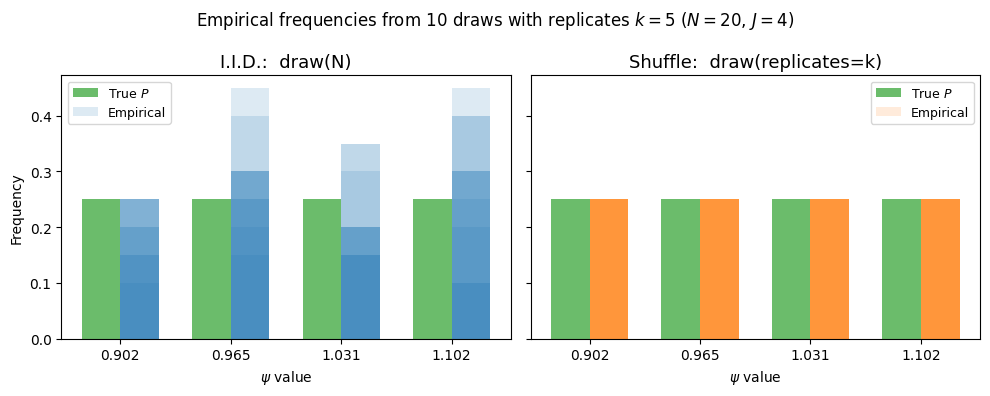

With draw(replicates=k), every repetition gives exactly 1/J per outcome.


In [3]:
# Compare i.i.d. draw(N) vs shuffled draw(replicates=k), 10 repetitions
n_reps = 10
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
bar_width = 0.35
x_pos = np.arange(J_demo)

for ax, use_replicates, title in [
    (axes[0], False, "I.I.D.:  draw(N)"),
    (axes[1], True, "Shuffle:  draw(replicates=k)"),
]:
    ax.bar(
        x_pos - bar_width / 2,
        P_demo,
        bar_width,
        label="True $P$",
        alpha=0.7,
        color="C2",
    )
    for r in range(n_reps):
        F_r = DiscreteDistribution(P_demo, X_demo, seed=r)
        if use_replicates:
            draws = F_r.draw(replicates=k_demo)
        else:
            draws = F_r.draw(N_demo)
        freq = empirical_freq(draws, X_demo)
        ax.bar(
            x_pos + bar_width / 2,
            freq,
            bar_width,
            alpha=0.15,
            color="C0" if not use_replicates else "C1",
            label="Empirical" if r == 0 else None,
        )
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f"{v:.3f}" for v in X_demo])
    ax.set_xlabel(r"$\psi$ value")
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Frequency")
fig.suptitle(
    f"Empirical frequencies from {n_reps} draws with replicates $k = {k_demo}$ ($N = {N_demo}$, $J = {J_demo}$)",
    fontsize=12,
)
fig.tight_layout()
plt.show()
print("With draw(replicates=k), every repetition gives exactly 1/J per outcome.")

# Time-series variance of the cross-sectional mean

In a simulation with $N$ agents, the cross-sectional mean of $\mathbf{p}$ (or $\log\mathbf{p}$) fluctuates from period to period.  The **time-series variance** of this mean quantifies how noisy the simulation's aggregate dynamics are.

After an initial transient, $\bar{\ell}_n = \frac{1}{N}\sum_i \log\mathbf{p}_{i,n}$ follows an approximate AR(1):

$$\bar{\ell}_{n+1} \approx (1-d)\,\bar{\ell}_n + \mu + \eta_n$$

where $\eta_n$ has two independent components:
- **Death noise:** agents who die (and get replaced at $\log\mathbf{p} = 0$) perturb the mean.  Variance $\approx \frac{d(1-d)}{N}\bigl(V_\infty + E_\infty^2\bigr)$, where $V_\infty, E_\infty$ are the ergodic cross-sectional variance and mean of $\log\mathbf{p}$.
- **Shock noise:** the empirical mean of $\log\psi$ deviates from $\mu$.  With i.i.d. draws, variance $= \sigma^2/N$.  With **shuffle at perfect $N$**, this is **exactly zero**.

### Analytical formula

The ergodic time-series variance of an AR(1) with coefficient $\rho = 1-d$ and innovation variance $v$ is $v/(1-\rho^2)$.  So:

$$\text{Var}_{\text{ts}}^{\text{shf}} = \frac{(1-d)(V_\infty + E_\infty^2)}{N(2-d)}, \qquad
\text{Var}_{\text{ts}}^{\text{iid}} = \text{Var}_{\text{ts}}^{\text{shf}} + \frac{\sigma^2}{N\,d(2-d)}$$

Both scale as $1/N$, so the **variance-reduction ratio is constant** in $N$:

$$R = \frac{\text{Var}_{\text{ts}}^{\text{iid}}}{\text{Var}_{\text{ts}}^{\text{shf}}} = 1 + \frac{\sigma^2}{d(1-d)(V_\infty + E_\infty^2)}$$

In [4]:
# --- Parameters ---
J = 4  # equiprobable permanent shock outcomes
death_prob = 0.02
T = 500  # total periods
burn = 100  # discard first 100 periods

# Sweep over replicates: N = k * J
replicates = [1, 2, 5, 10, 25, 50, 100, 250]

# Equiprobable permanent shock distribution, E[psi] = 1
log_psi_spread = 0.1
log_psi_vals = np.linspace(-log_psi_spread, log_psi_spread, J)
psi_vals = np.exp(log_psi_vals)
psi_vals = psi_vals / np.mean(psi_vals)
P_equi = np.ones(J) / J

mu = np.mean(np.log(psi_vals))
sigma2 = np.var(np.log(psi_vals))
d = death_prob

# Ergodic cross-sectional moments
V_erg = (1 - d) / d * sigma2 + (1 - d) / d**2 * mu**2  # Var(log p)
E_erg = (1 - d) * mu / d  # E[log p]


# Theoretical time-series variances (functions of N)
def theory_ts_var_shf(N):
    return (1 - d) * (V_erg + E_erg**2) / (N * (2 - d))


def theory_ts_var_iid(N):
    return theory_ts_var_shf(N) + sigma2 / (N * d * (2 - d))


R_theory = 1 + sigma2 / (d * (1 - d) * (V_erg + E_erg**2))

print(f"J = {J},  d = {death_prob},  T = {T},  burn-in = {burn}")
print(f"mu = {mu:.6f},  sigma^2 = {sigma2:.6f}")
print(f"Ergodic V_inf = {V_erg:.6f},  E_inf = {E_erg:.6f}")
print(f"V_inf + E_inf^2 = {V_erg + E_erg**2:.6f}")
print(f"\nTheoretical variance-reduction ratio R = {R_theory:.3f}")
print(f"Replicates k: {replicates}  →  N: {[k * J for k in replicates]}")

J = 4,  d = 0.02,  T = 500,  burn-in = 100
mu = -0.002776,  sigma^2 = 0.005556
Ergodic V_inf = 0.291103,  E_inf = -0.136026
V_inf + E_inf^2 = 0.309606

Theoretical variance-reduction ratio R = 1.916
Replicates k: [1, 2, 5, 10, 25, 50, 100, 250]  →  N: [4, 8, 20, 40, 100, 200, 400, 1000]


`# Run simulations for each N, compute time-series variance of mean(pLvl) and mean(log pLvl):`

In [5]:
def simulate_one(k, J, T, psi_vals, P_equi, death_prob, seed, shuffle):
    """Run one simulation, return time series of mean(pLvl) and mean(log pLvl).

    k : int — number of replicates (N = k * J)
    """
    N = k * J
    rng = np.random.default_rng(seed)
    F = DiscreteDistribution(P_equi, psi_vals, seed=seed + 1000)

    log_pLvl = np.zeros(N)
    mean_log = np.zeros(T)
    mean_lvl = np.zeros(T)

    for t in range(T):
        dies = rng.random(N) < death_prob
        log_pLvl[dies] = 0.0
        if shuffle:
            psi_draws = F.draw(replicates=k)
        else:
            psi_draws = F.draw(N)
        log_pLvl += np.log(psi_draws)
        mean_log[t] = np.mean(log_pLvl)
        mean_lvl[t] = np.mean(np.exp(log_pLvl))

    return mean_log, mean_lvl


# Average time-series variance over several seeds for robustness
n_seeds = 10

ts_var_log_iid = np.zeros(len(replicates))
ts_var_log_shf = np.zeros(len(replicates))
ts_var_lvl_iid = np.zeros(len(replicates))
ts_var_lvl_shf = np.zeros(len(replicates))

for ri, k in enumerate(replicates):
    N = k * J
    vlog_iid, vlog_shf, vlvl_iid, vlvl_shf = [], [], [], []

    for s in range(n_seeds):
        ml_i, mp_i = simulate_one(
            k, J, T, psi_vals, P_equi, death_prob, seed=s, shuffle=False
        )
        ml_s, mp_s = simulate_one(
            k, J, T, psi_vals, P_equi, death_prob, seed=s + 500, shuffle=True
        )

        # Time-series variance after burn-in
        vlog_iid.append(np.var(ml_i[burn:]))
        vlog_shf.append(np.var(ml_s[burn:]))
        vlvl_iid.append(np.var(mp_i[burn:]))
        vlvl_shf.append(np.var(mp_s[burn:]))

    ts_var_log_iid[ri] = np.mean(vlog_iid)
    ts_var_log_shf[ri] = np.mean(vlog_shf)
    ts_var_lvl_iid[ri] = np.mean(vlvl_iid)
    ts_var_lvl_shf[ri] = np.mean(vlvl_shf)

    ratio_log = (
        ts_var_log_iid[ri] / ts_var_log_shf[ri]
        if ts_var_log_shf[ri] > 0
        else float("inf")
    )
    ratio_lvl = (
        ts_var_lvl_iid[ri] / ts_var_lvl_shf[ri]
        if ts_var_lvl_shf[ri] > 0
        else float("inf")
    )
    print(
        f"k={int(k):>3d}  N={N:>4d}  "
        f"log: iid={ts_var_log_iid[ri]:.2e} shf={ts_var_log_shf[ri]:.2e} ratio={ratio_log:.2f}x  |  "
        f"lvl: iid={ts_var_lvl_iid[ri]:.2e} shf={ts_var_lvl_shf[ri]:.2e} ratio={ratio_lvl:.2f}x"
    )

k=  1  N=   4  log: iid=4.13e-02 shf=2.22e-02 ratio=1.86x  |  lvl: iid=3.23e-02 shf=2.23e-02 ratio=1.45x
k=  2  N=   8  log: iid=2.90e-02 shf=1.51e-02 ratio=1.92x  |  lvl: iid=3.69e-02 shf=1.48e-02 ratio=2.49x
k=  5  N=  20  log: iid=9.04e-03 shf=6.18e-03 ratio=1.46x  |  lvl: iid=1.34e-02 shf=8.22e-03 ratio=1.63x
k= 10  N=  40  log: iid=6.56e-03 shf=3.15e-03 ratio=2.09x  |  lvl: iid=7.84e-03 shf=5.40e-03 ratio=1.45x
k= 25  N= 100  log: iid=2.67e-03 shf=1.24e-03 ratio=2.15x  |  lvl: iid=3.06e-03 shf=1.46e-03 ratio=2.09x
k= 50  N= 200  log: iid=1.51e-03 shf=5.20e-04 ratio=2.90x  |  lvl: iid=1.83e-03 shf=1.01e-03 ratio=1.81x
k=100  N= 400  log: iid=7.78e-04 shf=2.81e-04 ratio=2.77x  |  lvl: iid=9.72e-04 shf=4.81e-04 ratio=2.02x
k=250  N=1000  log: iid=2.75e-04 shf=1.42e-04 ratio=1.94x  |  lvl: iid=2.69e-04 shf=1.65e-04 ratio=1.63x


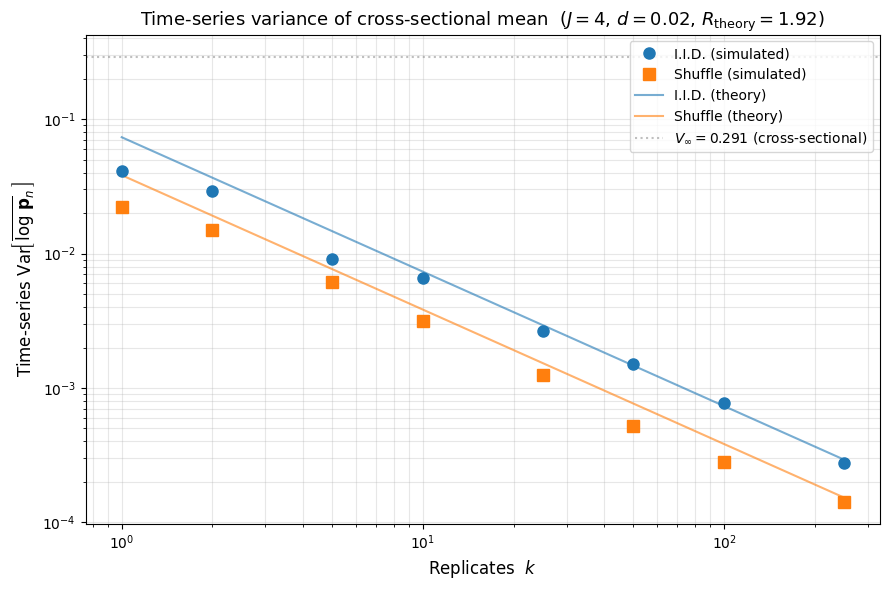

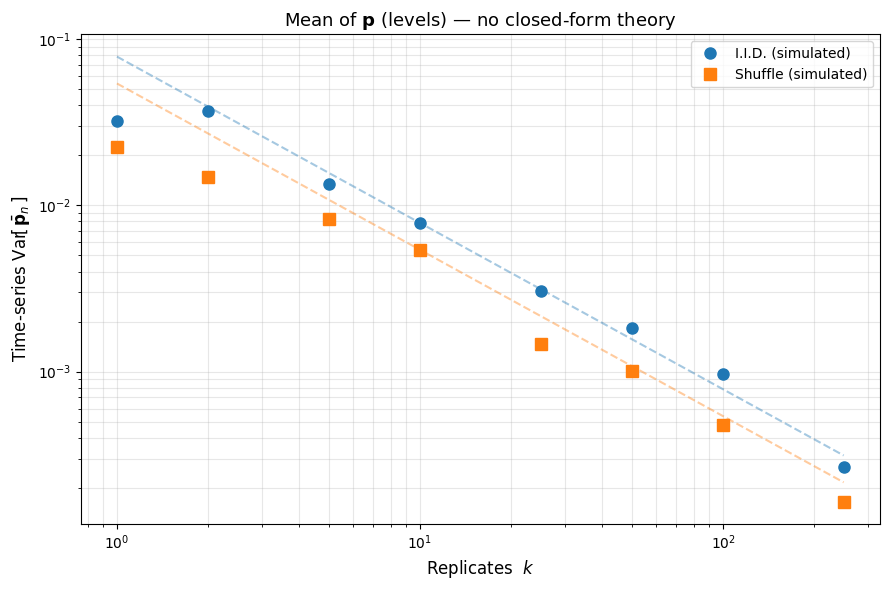

In [6]:
# --- Main figure: time-series variance of mean(log pLvl) vs replicates ---
# with theoretical predictions overlaid

reps = np.array(replicates)
k_fine = np.logspace(0, np.log10(reps[-1]), 200)
N_fine = k_fine * J

fig, ax = plt.subplots(figsize=(9, 6))

# Simulated
ax.loglog(
    reps,
    ts_var_log_iid,
    "o",
    color="C0",
    markersize=8,
    zorder=5,
    label="I.I.D. (simulated)",
)
ax.loglog(
    reps,
    ts_var_log_shf,
    "s",
    color="C1",
    markersize=8,
    zorder=5,
    label="Shuffle (simulated)",
)

# Theory
ax.loglog(
    k_fine,
    theory_ts_var_iid(N_fine),
    "-",
    color="C0",
    alpha=0.6,
    label="I.I.D. (theory)",
)
ax.loglog(
    k_fine,
    theory_ts_var_shf(N_fine),
    "-",
    color="C1",
    alpha=0.6,
    label="Shuffle (theory)",
)

# Ergodic cross-sectional variance as reference
ax.axhline(
    V_erg,
    color="gray",
    linestyle=":",
    alpha=0.5,
    label=f"$V_\\infty = {V_erg:.3f}$ (cross-sectional)",
)

ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(
    r"Time-series Var$\!\left[\,\overline{\log\,\mathbf{p}}_n\,\right]$", fontsize=12
)
ax.set_title(
    f"Time-series variance of cross-sectional mean  "
    f"($J={J}$, $d={death_prob}$, $R_{{\\mathrm{{theory}}}}={R_theory:.2f}$)",
    fontsize=13,
)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

# --- Same for levels ---
fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(
    reps, ts_var_lvl_iid, "o", color="C0", markersize=8, label="I.I.D. (simulated)"
)
ax.loglog(
    reps, ts_var_lvl_shf, "s", color="C1", markersize=8, label="Shuffle (simulated)"
)
# No clean theory for levels, just 1/k reference lines
ref_iid = ts_var_lvl_iid[3] * reps[3] / reps
ref_shf = ts_var_lvl_shf[3] * reps[3] / reps
ax.loglog(reps, ref_iid, "--", color="C0", alpha=0.4)
ax.loglog(reps, ref_shf, "--", color="C1", alpha=0.4)
ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(r"Time-series Var$\!\left[\,\bar{\mathbf{p}}_n\,\right]$", fontsize=12)
ax.set_title(r"Mean of $\mathbf{p}$ (levels) — no closed-form theory", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

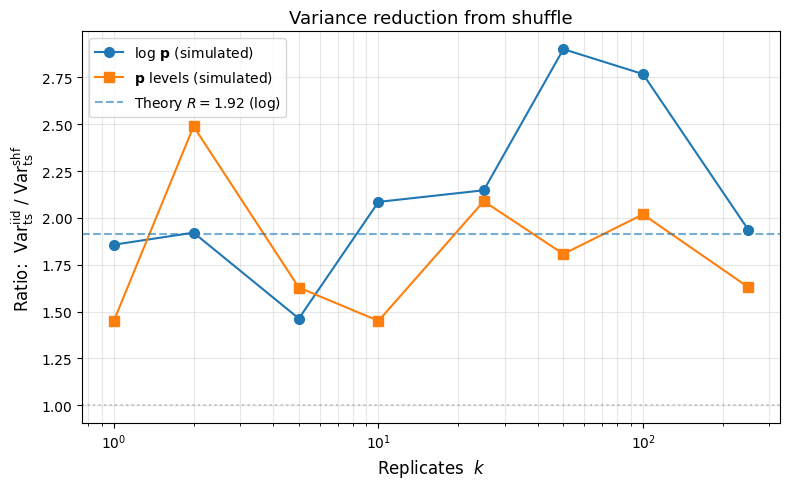

In [7]:
# --- Ratio plot with theoretical prediction ---
ratio_log = ts_var_log_iid / ts_var_log_shf
ratio_lvl = ts_var_lvl_iid / ts_var_lvl_shf

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogx(
    reps, ratio_log, "o-", label=r"$\log\,\mathbf{p}$ (simulated)", markersize=7
)
ax.semilogx(
    reps, ratio_lvl, "s-", label=r"$\mathbf{p}$ levels (simulated)", markersize=7
)
ax.axhline(
    R_theory,
    color="C0",
    linestyle="--",
    alpha=0.6,
    label=f"Theory $R = {R_theory:.2f}$ (log)",
)
ax.axhline(1, color="gray", linestyle=":", alpha=0.4)
ax.set_xlabel("Replicates  $k$", fontsize=12)
ax.set_ylabel(
    r"Ratio:  Var$_{\mathrm{ts}}^{\mathrm{iid}}$ / Var$_{\mathrm{ts}}^{\mathrm{shf}}$",
    fontsize=12,
)
ax.set_title("Variance reduction from shuffle", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

# Summary

The time-series variance of $\overline{\log\mathbf{p}}$ has two components, both scaling as $1/N$:

| Source | Variance contribution | Shuffle? |
|--------|----------------------|----------|
| Death noise | $\frac{(1-d)(V_\infty + E_\infty^2)}{N(2-d)}$ | Same |
| Shock noise | $\frac{\sigma^2}{Nd(2-d)}$ | **Eliminated** |

The variance-reduction ratio $R = 1 + \frac{\sigma^2}{d(1-d)(V_\infty + E_\infty^2)}$ is a **constant** independent of $N$.  For these parameters, $R \approx 1.9$: shuffle roughly halves the time-series variance, regardless of how many agents are simulated.

The log-log plot confirms that simulated points lie on the theoretical curves, validating the AR(1) approximation.  The $V_\infty$ reference line shows the scale of cross-sectional dispersion for context — the time-series variance of the *mean* is orders of magnitude smaller (by a factor of $\sim N$).

# Application: Markov employment model with shuffled income shocks

The simple permanent-income simulation above demonstrates the mechanics of shuffled draws.  Now we apply the same technique to a more realistic setting: a **Markov employment model** inspired by [HAFiscal](https://github.com/econ-ark/HAFiscal), stripped of aggregate shocks and fiscal experiments.

## Model overview

Agents transition between **7 discrete employment states**:

| State | Label | Income (as fraction of $\mathbf{p}$) |
|:-----:|-------|--------------------------------------|
| 0 | Employed | Lognormal permanent ($\psi$) and transitory ($\theta$) shocks |
| 1 | Unemployed, UI quarter 1 | Deterministic: $\psi=1$, $\theta=0.7$ |
| 2 | Unemployed, UI quarter 2 | Deterministic: $\psi=1$, $\theta=0.7$ |
| 3 | Unemployed, no benefits, quarter 3 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 4 | Unemployed, no benefits, quarter 4 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 5 | Unemployed, no benefits, quarter 5 | Deterministic: $\psi=1$, $\theta=0.5$ |
| 6 | Unemployed, no benefits, quarter 6 | Deterministic: $\psi=1$, $\theta=0.5$ → **forced reemployment** |

Unemployment spells are capped at 6 quarters: state 6 transitions to employment with probability 1.  This ensures a finite state space with rational steady-state probabilities, so `income_shuffle` can achieve exact frequency matching within each state.

### Transition matrix

Parameterized by:
- Steady-state unemployment rate $u = 0.05$ (quarterly)
- Average unemployment duration $\bar{U} = 1.5$ quarters
- UI benefit duration: 2 quarters (states 1–2)

The reemployment probability from any unemployed state is $1 - U_{\text{persist}} = 1/\bar{U} \approx 0.667$, except state 6 which forces reemployment.

### Key question

With `income_shuffle=True`, the employed agents' income shocks ($\psi, \theta$) are drawn with exact frequency matching.  The Markov transitions themselves remain stochastic.  Does eliminating the shock-noise component measurably reduce the time-series variance of aggregate consumption?

In [8]:
from HARK.ConsumptionSaving.ConsMarkovModel import MarkovConsumerType
from HARK.distributions import (
    DiscreteDistribution,
    DiscreteDistributionLabeled,
    combine_indep_dstns,
    MeanOneLogNormal,
)

# --- Markov transition matrix (7 states) ---
K = 7
Urate = 0.05  # quarterly unemployment rate
Uspell = 1.5  # average unemployment duration (quarters)
U_persist = 1 - 1 / Uspell  # prob of staying unemployed
E_persist = 1 - Urate * (1 - U_persist) / (1 - Urate)  # prob of staying employed

TM = np.zeros((K, K))
TM[0, 0] = E_persist
TM[0, 1] = 1 - E_persist  # employed → unemployed (UI q1)
for s in range(1, 6):
    TM[s, 0] = 1 - U_persist  # reemployment
    TM[s, s + 1] = U_persist  # advance to next unemployment quarter
TM[6, 0] = 1.0  # forced reemployment after 6 quarters

print("Transition matrix (rows = from, cols = to):")
state_labels = ["E", "U1", "U2", "U3", "U4", "U5", "U6"]
header = "     " + "  ".join(f"{s:>6s}" for s in state_labels)
print(header)
for i, row in enumerate(TM):
    print(f"  {state_labels[i]:>2s}  " + "  ".join(f"{v:6.4f}" for v in row))

# Verify: steady-state distribution
eigvals, eigvecs = np.linalg.eig(TM.T)
ss_idx = np.argmin(np.abs(eigvals - 1.0))
ss_dist = np.real(eigvecs[:, ss_idx])
ss_dist = ss_dist / ss_dist.sum()
print("\nSteady-state distribution:")
for s, p in zip(state_labels, ss_dist):
    print(f"  {s}: {p:.4f}")
print(f"  Total unemployment: {ss_dist[1:].sum():.4f}")

Transition matrix (rows = from, cols = to):
          E      U1      U2      U3      U4      U5      U6
   E  0.9649  0.0351  0.0000  0.0000  0.0000  0.0000  0.0000
  U1  0.6667  0.0000  0.3333  0.0000  0.0000  0.0000  0.0000
  U2  0.6667  0.0000  0.0000  0.3333  0.0000  0.0000  0.0000
  U3  0.6667  0.0000  0.0000  0.0000  0.3333  0.0000  0.0000
  U4  0.6667  0.0000  0.0000  0.0000  0.0000  0.3333  0.0000
  U5  0.6667  0.0000  0.0000  0.0000  0.0000  0.0000  0.3333
  U6  1.0000  0.0000  0.0000  0.0000  0.0000  0.0000  0.0000

Steady-state distribution:
  E: 0.9501
  U1: 0.0333
  U2: 0.0111
  U3: 0.0037
  U4: 0.0012
  U5: 0.0004
  U6: 0.0001
  Total unemployment: 0.0499


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [9]:
# --- Income shock distributions by state ---

# Employed: lognormal permanent + transitory shocks (HAFiscal calibration)
PermShkDstn_emp = MeanOneLogNormal(np.sqrt(0.003)).discretize(7, method="equiprobable")
TranShkDstn_emp = MeanOneLogNormal(np.sqrt(0.12)).discretize(7, method="equiprobable")
emp_dstn_raw = combine_indep_dstns(PermShkDstn_emp, TranShkDstn_emp)
emp_dstn = DiscreteDistributionLabeled(
    pmv=emp_dstn_raw.pmv,
    atoms=emp_dstn_raw.atoms,
    var_names=["PermShk", "TranShk"],
)

# Unemployed with UI (states 1-2): deterministic PermShk=1, TranShk=0.7
ui_dstn = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.7]]),
    var_names=["PermShk", "TranShk"],
)

# Unemployed, no benefits (states 3-6): deterministic PermShk=1, TranShk=0.5
nob_dstn = DiscreteDistributionLabeled(
    pmv=np.ones(1),
    atoms=np.array([[1.0], [0.5]]),
    var_names=["PermShk", "TranShk"],
)

# IncShkDstn: list of lists, [period][state]
IncShkDstn_markov = [
    [emp_dstn, ui_dstn, ui_dstn, nob_dstn, nob_dstn, nob_dstn, nob_dstn]
]

# Marginal distributions for the solver
PermShkDstn_unemp = DiscreteDistribution(np.ones(1), np.array([1.0]))
TranShkDstn_ui = DiscreteDistribution(np.ones(1), np.array([0.7]))
TranShkDstn_nob = DiscreteDistribution(np.ones(1), np.array([0.5]))

PermShkDstn_markov = [[PermShkDstn_emp] + [PermShkDstn_unemp] * 6]
TranShkDstn_markov = [[TranShkDstn_emp] + [TranShkDstn_ui] * 2 + [TranShkDstn_nob] * 4]

print(
    f"Employed income distribution: {emp_dstn.atoms.shape[1]} joint atoms (7×7 perm×tran)"
)
print(f"  E[PermShk] = {emp_dstn.atoms[0] @ emp_dstn.pmv:.4f}")
print(f"  E[TranShk] = {emp_dstn.atoms[1] @ emp_dstn.pmv:.4f}")
print(f"Unemployed (UI):  TranShk = {ui_dstn.atoms[1, 0]:.1f}")
print(f"Unemployed (NoB): TranShk = {nob_dstn.atoms[1, 0]:.1f}")

Employed income distribution: 49 joint atoms (7×7 perm×tran)
  E[PermShk] = 1.0000
  E[TranShk] = 1.0000
Unemployed (UI):  TranShk = 0.7
Unemployed (NoB): TranShk = 0.5


In [10]:
# --- Build and solve the Markov consumer ---

# Initial Markov distribution: everyone starts employed
MrkvPrbsInit = np.zeros(K)
MrkvPrbsInit[0] = 1.0
MrkvInitDstn = DiscreteDistribution(MrkvPrbsInit, np.arange(K))

# Common parameters (HAFiscal HS-graduate calibration, quarterly)
common_params = dict(
    cycles=0,
    T_cycle=1,
    construct=False,  # we supply IncShkDstn, MrkvArray, etc. directly
    CRRA=2.0,
    DiscFac=0.966,
    Rfree=[np.full(K, 1.01)],
    LivPrb=[np.full(K, 0.99375)],
    PermGroFac=[np.array([1.00453] + [1.0] * 6)],  # growth only when employed
    BoroCnstArt=0.0,
    MrkvArray=[TM],
    IncShkDstn=IncShkDstn_markov,
    PermShkDstn=PermShkDstn_markov,
    TranShkDstn=TranShkDstn_markov,
    MrkvPrbsInit=MrkvPrbsInit,
    MrkvInitDstn=MrkvInitDstn,
    aXtraMin=0.001,
    aXtraMax=40,
    aXtraCount=48,
    aXtraNestFac=3,
    aXtraExtra=None,
    kLogInitMean=-12.0,
    kLogInitStd=0.0,
    kNrmInitCount=15,
    pLogInitMean=0.0,
    pLogInitStd=0.0,
    pLvlInitCount=15,
)


def make_markov_agent(shuffle, N=1400, T_sim=400, seed=0):
    """Create, solve, and simulate a Markov consumer with given shuffle setting."""
    agent = MarkovConsumerType(
        **common_params,
        income_shuffle=shuffle,
        AgentCount=N,
        T_sim=T_sim,
        seed=seed,
    )
    agent.construct("aXtraGrid", "solution_terminal", "kNrmInitDstn", "pLvlInitDstn")
    agent.solve()
    agent.track_vars = ["cNrm", "pLvl", "aNrm"]
    agent.initialize_sim()
    agent.simulate()
    return agent


# Quick test: solve once
test_agent = make_markov_agent(shuffle=False, N=700, T_sim=10)
print("Model solved and simulated successfully.")
print(f"  AgentCount = {test_agent.AgentCount}")
print(
    f"  Markov state counts: {dict(zip(state_labels, np.bincount(test_agent.shocks['Mrkv'].astype(int), minlength=K)))}"
)
print(f"  Mean cNrm = {np.mean(test_agent.controls['cNrm']):.4f}")

Model solved and simulated successfully.
  AgentCount = 700
  Markov state counts: {'E': np.int64(671), 'U1': np.int64(17), 'U2': np.int64(7), 'U3': np.int64(3), 'U4': np.int64(2), 'U5': np.int64(0), 'U6': np.int64(0)}
  Mean cNrm = 0.9651


`# Compare time-series variance of aggregate consumption: shuffle vs i.i.d.`

In [11]:
# --- Compare time-series variance across population sizes ---
# Use mean(cNrm) — normalized consumption — which is stationary in the
# ergodic steady state, unlike mean(cNrm * pLvl) which trends with pLvl growth.

N_agents_list = [350, 700, 1400, 2800, 4900]
T_sim = 400
burn = 100
n_seeds = 5  # average over seeds for robustness

ts_var_iid = np.zeros(len(N_agents_list))
ts_var_shf = np.zeros(len(N_agents_list))

for ni, N in enumerate(N_agents_list):
    v_iid, v_shf = [], []
    for s in range(n_seeds):
        for shuffle, vlist in [(False, v_iid), (True, v_shf)]:
            agent = make_markov_agent(shuffle=shuffle, N=N, T_sim=T_sim, seed=s)
            # Normalized consumption (stationary in ergodic steady state)
            mean_cNrm = np.array(
                [np.mean(agent.history["cNrm"][t]) for t in range(T_sim)]
            )
            vlist.append(np.var(mean_cNrm[burn:]))

    ts_var_iid[ni] = np.mean(v_iid)
    ts_var_shf[ni] = np.mean(v_shf)
    ratio = ts_var_iid[ni] / ts_var_shf[ni] if ts_var_shf[ni] > 0 else float("inf")
    print(
        f"N={N:>5d}  iid={ts_var_iid[ni]:.3e}  shf={ts_var_shf[ni]:.3e}  ratio={ratio:.2f}x"
    )

N=  350  iid=4.232e-05  shf=1.065e-05  ratio=3.97x
N=  700  iid=2.762e-05  shf=5.295e-06  ratio=5.22x
N= 1400  iid=1.297e-05  shf=2.540e-06  ratio=5.11x
N= 2800  iid=5.763e-06  shf=1.156e-06  ratio=4.98x
N= 4900  iid=2.342e-06  shf=7.401e-07  ratio=3.16x


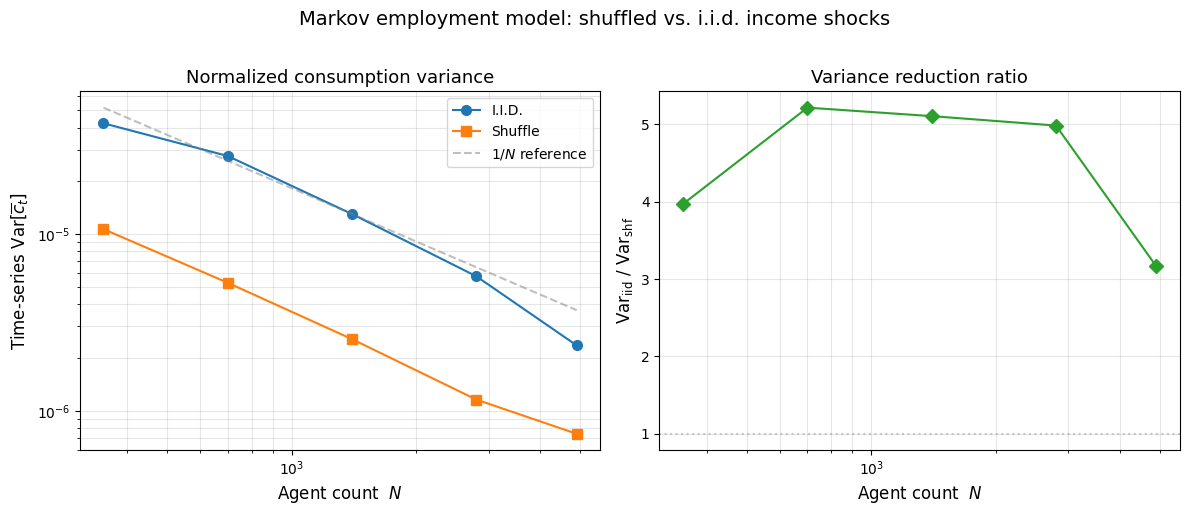

In [12]:
# --- Variance comparison plot ---

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: time-series variance vs N
ax = axes[0]
ax.loglog(N_agents_list, ts_var_iid, "o-", color="C0", markersize=7, label="I.I.D.")
ax.loglog(N_agents_list, ts_var_shf, "s-", color="C1", markersize=7, label="Shuffle")
# Reference 1/N slope
ref_N = np.array(N_agents_list, dtype=float)
ref_line = ts_var_iid[2] * N_agents_list[2] / ref_N
ax.loglog(ref_N, ref_line, "--", color="gray", alpha=0.5, label="$1/N$ reference")
ax.set_xlabel("Agent count  $N$", fontsize=12)
ax.set_ylabel(r"Time-series Var$[\overline{c}_t]$", fontsize=12)
ax.set_title("Normalized consumption variance", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, which="both", alpha=0.3)

# Right: variance ratio
ax = axes[1]
ratio = ts_var_iid / ts_var_shf
ax.semilogx(N_agents_list, ratio, "D-", color="C2", markersize=7)
ax.axhline(1, color="gray", linestyle=":", alpha=0.4)
ax.set_xlabel("Agent count  $N$", fontsize=12)
ax.set_ylabel(r"Var$_{\mathrm{iid}}$ / Var$_{\mathrm{shf}}$", fontsize=12)
ax.set_title("Variance reduction ratio", fontsize=13)
ax.grid(True, which="both", alpha=0.3)

fig.suptitle(
    "Markov employment model: shuffled vs. i.i.d. income shocks",
    fontsize=14,
    y=1.02,
)
fig.tight_layout()
plt.show()

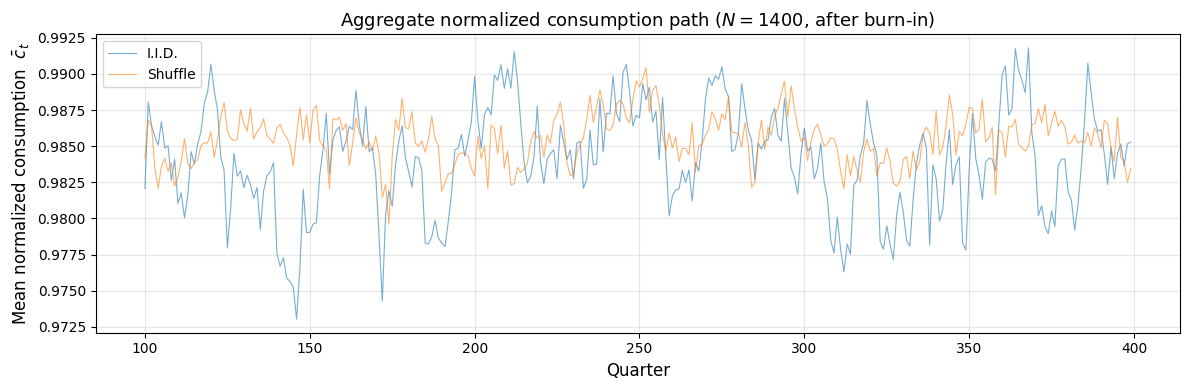

Time-series std(mean cNrm):
  I.I.D.:   0.003588
  Shuffle:  0.001697
  Ratio:    2.115x


In [13]:
# --- Time-series plot: a single simulation at N=1400 ---

N_demo_mrkv = 1400
T_demo_mrkv = 400

agent_iid = make_markov_agent(shuffle=False, N=N_demo_mrkv, T_sim=T_demo_mrkv, seed=42)
agent_shf = make_markov_agent(shuffle=True, N=N_demo_mrkv, T_sim=T_demo_mrkv, seed=42)

mean_c_iid = np.array(
    [np.mean(agent_iid.history["cNrm"][t]) for t in range(T_demo_mrkv)]
)
mean_c_shf = np.array(
    [np.mean(agent_shf.history["cNrm"][t]) for t in range(T_demo_mrkv)]
)

fig, ax = plt.subplots(figsize=(12, 4))
quarters = np.arange(T_demo_mrkv)
ax.plot(
    quarters[burn:],
    mean_c_iid[burn:],
    alpha=0.6,
    linewidth=0.8,
    color="C0",
    label="I.I.D.",
)
ax.plot(
    quarters[burn:],
    mean_c_shf[burn:],
    alpha=0.6,
    linewidth=0.8,
    color="C1",
    label="Shuffle",
)
ax.set_xlabel("Quarter", fontsize=12)
ax.set_ylabel(r"Mean normalized consumption  $\bar{c}_t$", fontsize=12)
ax.set_title(
    f"Aggregate normalized consumption path ($N = {N_demo_mrkv}$, after burn-in)",
    fontsize=13,
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print("Time-series std(mean cNrm):")
print(f"  I.I.D.:   {np.std(mean_c_iid[burn:]):.6f}")
print(f"  Shuffle:  {np.std(mean_c_shf[burn:]):.6f}")
print(f"  Ratio:    {np.std(mean_c_iid[burn:]) / np.std(mean_c_shf[burn:]):.3f}x")

## Discussion

In this Markov employment model, the shuffle eliminates sampling noise from the **income shock** dimension (permanent and transitory shocks for employed agents), but does **not** affect the **Markov transition** noise (which agents become unemployed).  Since unemployment transitions are themselves a major source of aggregate fluctuation, the variance reduction from shuffling the income shocks is more modest than in the pure permanent-income model above.

Three sources of simulation noise in aggregate consumption:
1. **Income shock noise** (employed agents): eliminated by shuffle
2. **Markov transition noise** (who becomes unemployed): unaffected by shuffle
3. **Death/rebirth noise**: unaffected by shuffle

The variance reduction ratio depends on the relative contribution of income shock noise to total simulation variance.  When Markov transitions dominate (high unemployment rate, large income drops on job loss), the ratio is closer to 1.  When income shocks dominate (low unemployment, high shock variance), the ratio is larger.

A natural extension would be to also shuffle the Markov transitions — assigning exactly the right number of agents to each state transition in each period.  This is not currently implemented in HARK but would eliminate source (2) as well.